In [173]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

In [174]:
#loading data
df=pd.read_csv('/content/online vs store shopping dataset.csv')
df.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store


In [175]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          11789 non-null  int64  
 1   monthly_income               11789 non-null  int64  
 2   daily_internet_hours         11789 non-null  float64
 3   smartphone_usage_years       11789 non-null  int64  
 4   social_media_hours           11789 non-null  float64
 5   online_payment_trust_score   11789 non-null  int64  
 6   tech_savvy_score             11789 non-null  int64  
 7   monthly_online_orders        11789 non-null  int64  
 8   monthly_store_visits         11789 non-null  int64  
 9   avg_online_spend             11789 non-null  int64  
 10  avg_store_spend              11789 non-null  int64  
 11  discount_sensitivity         11789 non-null  int64  
 12  return_frequency             11789 non-null  int64  
 13  avg_delivery_day

In [176]:
df.describe()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,return_frequency,avg_delivery_days,delivery_fee_sensitivity,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level
count,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,...,11789.00000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000
mean,48.729409,131704.282382,6.011367,7.597930,2.514471,5.498770,5.534312,24.677581,9.482144,74554.929341,...,4.46747,3.999661,5.468827,5.462041,5.518704,5.486386,5.485368,5.532021,5.448554,5.504114
std,17.899445,68120.726684,1.976811,4.011628,1.263047,2.880366,2.887251,14.431277,5.728825,43167.126595,...,2.88545,1.995881,2.870195,2.882177,2.867613,2.877918,2.877264,2.848796,2.872740,2.876561
min,18.000000,15005.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,523.000000,...,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,33.000000,72450.000000,4.600000,4.000000,1.600000,3.000000,3.000000,12.000000,5.000000,36797.000000,...,2.00000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,49.000000,131916.000000,6.000000,8.000000,2.500000,5.000000,6.000000,25.000000,9.000000,74859.000000,...,4.00000,4.000000,5.000000,5.000000,6.000000,5.000000,5.000000,6.000000,5.000000,6.000000
75%,64.000000,190505.000000,7.400000,11.000000,3.400000,8.000000,8.000000,37.000000,14.000000,112134.000000,...,7.00000,6.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
max,79.000000,249989.000000,12.000000,14.000000,6.000000,10.000000,10.000000,49.000000,19.000000,149996.000000,...,9.00000,7.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [177]:
# Checking Duplicates
df.duplicated().sum()

np.int64(0)

In [178]:
# checking nulls
df.isnull().sum()

,0
age,0
monthly_income,0
daily_internet_hours,0
smartphone_usage_years,0
social_media_hours,0
online_payment_trust_score,0
tech_savvy_score,0
monthly_online_orders,0
monthly_store_visits,0
avg_online_spend,0


In [179]:

# HANDLE MISSING VALUES

# numeric columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

# categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# fill numeric with median
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# fill categorical with mode
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# check again
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
age                            0
monthly_income                 0
daily_internet_hours           0
smartphone_usage_years         0
social_media_hours             0
online_payment_trust_score     0
tech_savvy_score               0
monthly_online_orders          0
monthly_store_visits           0
avg_online_spend               0
avg_store_spend                0
discount_sensitivity           0
return_frequency               0
avg_delivery_days              0
delivery_fee_sensitivity       0
free_return_importance         0
product_availability_online    0
impulse_buying_score           0
need_touch_feel_score          0
brand_loyalty_score            0
environmental_awareness        0
time_pressure_level            0
gender                         0
city_tier                      0
shopping_preference            0
dtype: int64


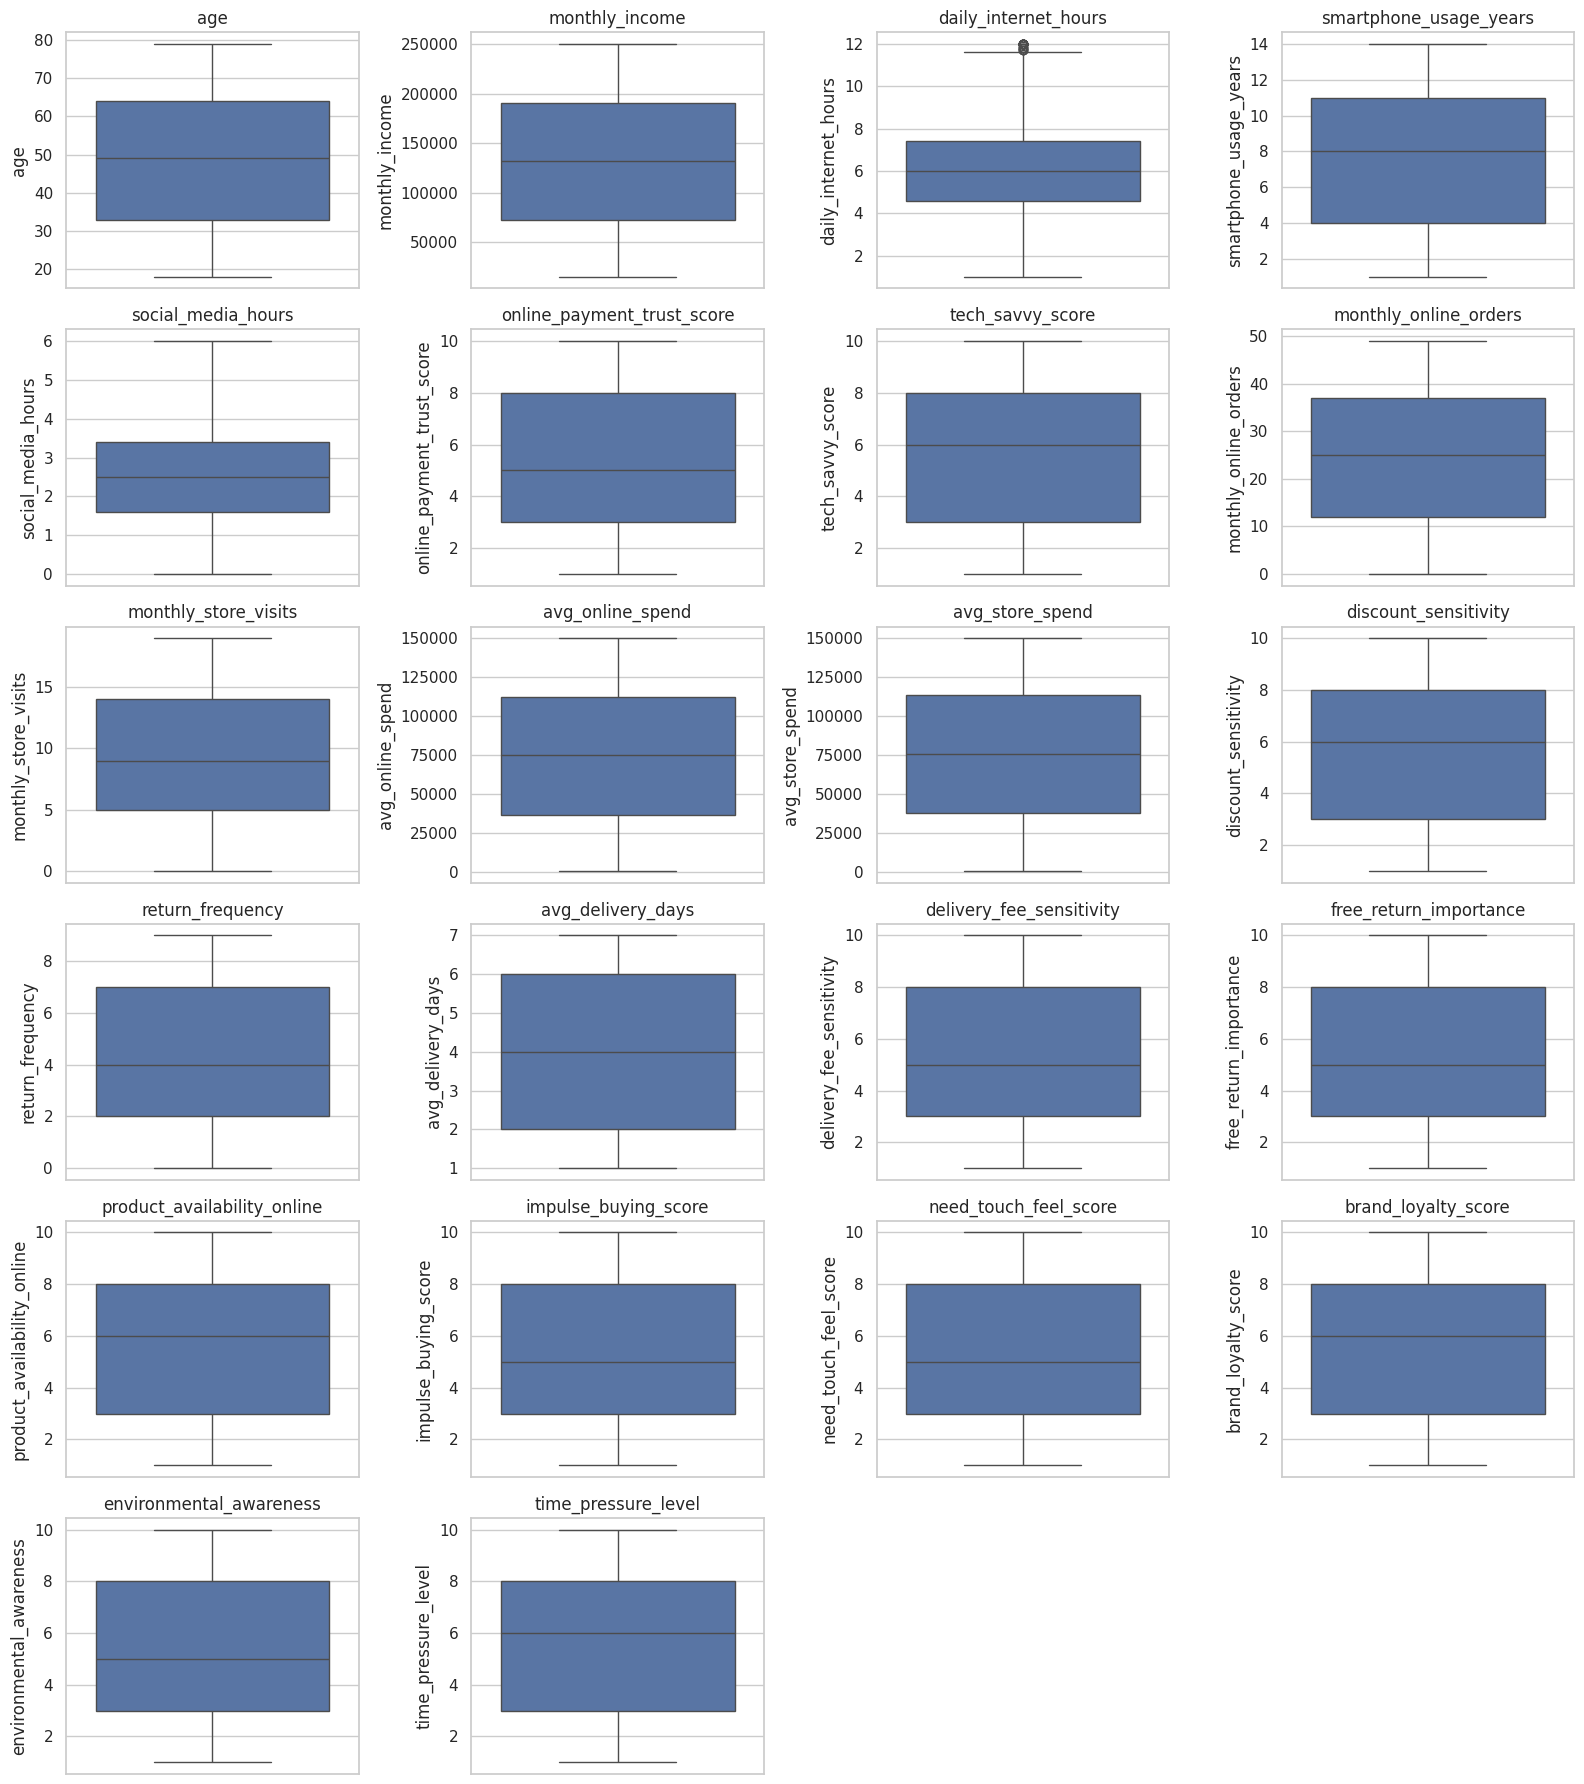

In [180]:
# Checking outliers
numeric_cols = df.select_dtypes(include=['float64','int64']).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

n_numeric_cols = len(numeric_cols)
cols_per_row = 4
rows_needed = (n_numeric_cols + cols_per_row - 1) // cols_per_row

plt.figure(figsize=(cols_per_row * 4, rows_needed * 3))
for i, col in enumerate(numeric_cols):
    plt.subplot(rows_needed, cols_per_row, i+1)
    sns.boxplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

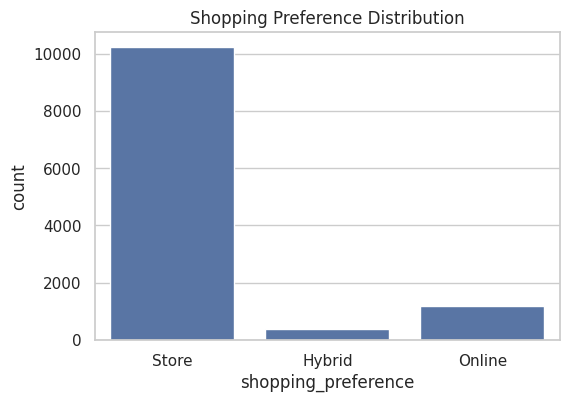

In [181]:
# EDA
# Target imbalance
plt.figure(figsize=(6,4))
sns.countplot(x="shopping_preference", data=df)
plt.title("Shopping Preference Distribution")
plt.show()

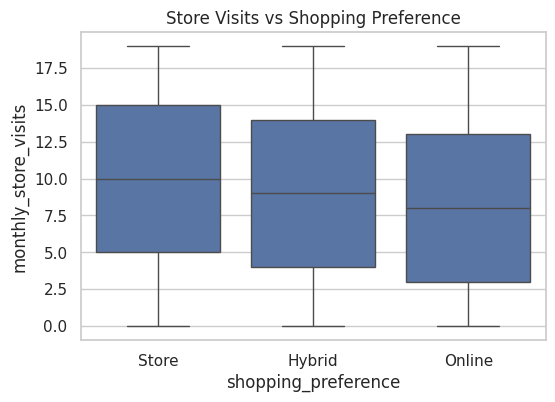

In [182]:
# Store behaviour indicator
plt.figure(figsize=(6,4))
sns.boxplot(x="shopping_preference", y="monthly_store_visits", data=df)
plt.title("Store Visits vs Shopping Preference")
plt.show()

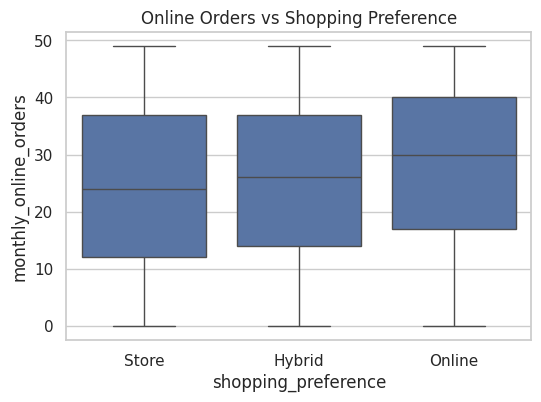

In [183]:
# Online behaviour indicator
plt.figure(figsize=(6,4))
sns.boxplot(x="shopping_preference", y="monthly_online_orders", data=df)
plt.title("Online Orders vs Shopping Preference")
plt.show()


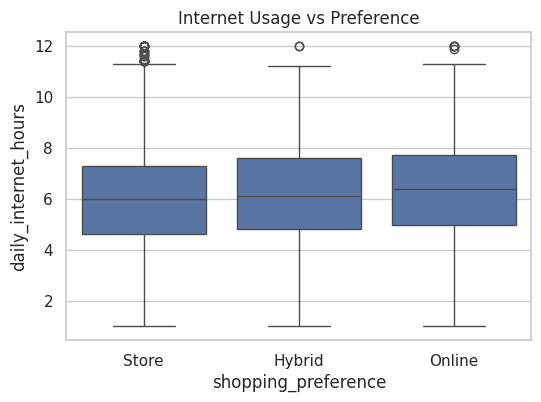

In [184]:
# Internet usage effect
plt.figure(figsize=(6,4))
sns.boxplot(x="shopping_preference", y="daily_internet_hours", data=df)
plt.title("Internet Usage vs Preference")
plt.show()

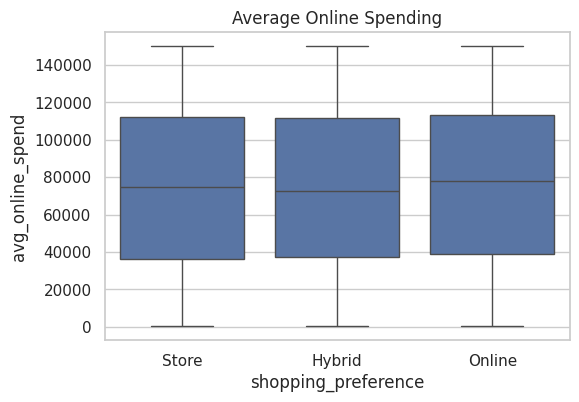

In [185]:
# Spending behaviour
plt.figure(figsize=(6,4))
sns.boxplot(x="shopping_preference", y="avg_online_spend", data=df)
plt.title("Average Online Spending")
plt.show()

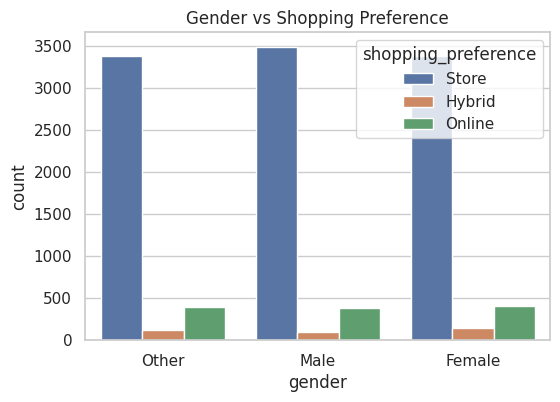

In [186]:
# Gender influence
plt.figure(figsize=(6,4))
sns.countplot(x="gender", hue="shopping_preference", data=df)
plt.title("Gender vs Shopping Preference")
plt.show()

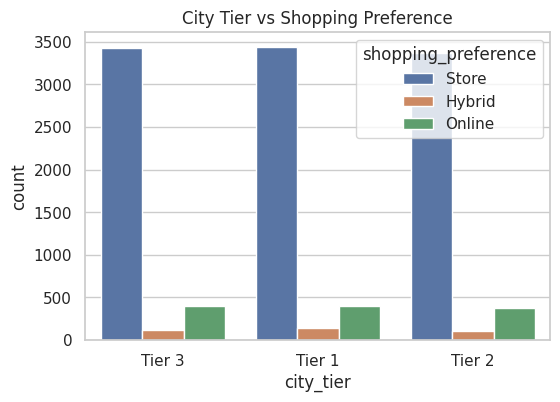

In [187]:
# City tier influence
plt.figure(figsize=(6,4))
sns.countplot(x="city_tier", hue="shopping_preference", data=df)
plt.title("City Tier vs Shopping Preference")
plt.show()

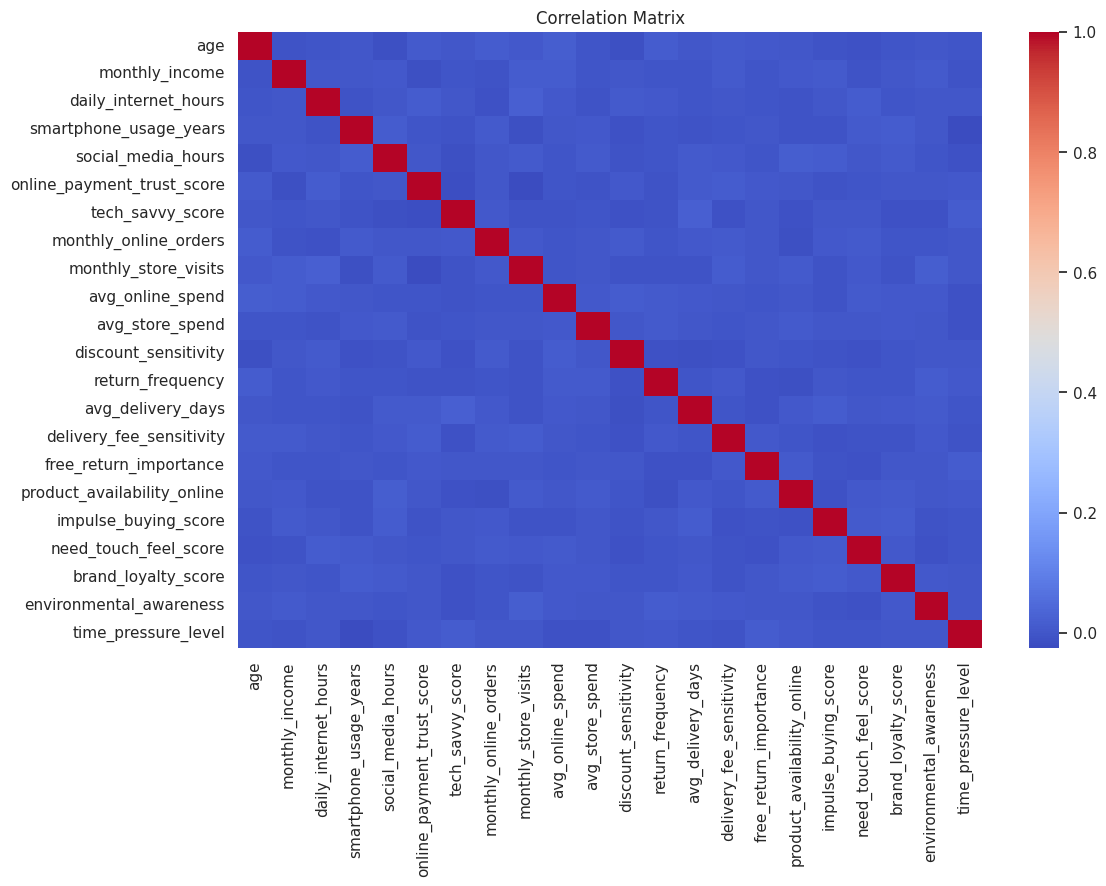

In [188]:
# Correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [189]:
# ENCODING

df["gender"] = df["gender"].map({"Male":1,"Female":0, "Other":2})

df["city_tier"] = df["city_tier"].map({
"Tier 1":2,
"Tier 2":1,
"Tier 3":0
})

In [190]:
# Encode target
le = LabelEncoder()
df["shopping_preference"] = le.fit_transform(df["shopping_preference"])


In [191]:
# FEATURE / TARGET SPLIT

X = df.drop("shopping_preference", axis=1)
y = df["shopping_preference"]

In [192]:
#  FEATURE SCALING

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [193]:
#  TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [194]:
# MODELING BEFORE HANDLING IMBALANCE


print("MODEL PERFORMANCE BEFORE SMOTE")


models = {
    "Logistic Regression": LogisticRegression(max_iter=300),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC()
}



results_before = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted")
    rec = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    results_before.append([name, acc, prec, rec, f1])

    print("\n", name)
    print(classification_report(y_test, y_pred))

MODEL PERFORMANCE BEFORE SMOTE

 Logistic Regression
              precision    recall  f1-score   support

           0       0.87      0.46      0.60        72
           1       0.93      0.99      0.96       224
           2       0.99      1.00      0.99      2062

    accuracy                           0.98      2358
   macro avg       0.93      0.82      0.85      2358
weighted avg       0.98      0.98      0.98      2358


 Random Forest
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        72
           1       0.87      0.91      0.89       224
           2       0.97      1.00      0.98      2062

    accuracy                           0.96      2358
   macro avg       0.61      0.64      0.62      2358
weighted avg       0.93      0.96      0.94      2358


 Gradient Boosting
              precision    recall  f1-score   support

           0       0.33      0.06      0.10        72
           1       0.86      0.94      0

In [195]:
print("\nModel Comparison BEFORE SMOTE")
print(results_before_df)


Model Comparison BEFORE SMOTE
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.981340   0.980029  0.981340  0.978625
2    Gradient Boosting  0.960984   0.945650  0.960984  0.950040
3                  SVM  0.959288   0.930305  0.959288  0.944546
1        Random Forest  0.957591   0.928644  0.957591  0.942875


In [196]:
#  HANDLE IMBALANCE WITH SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE Class Distribution:")
print(pd.Series(y_train_balanced).value_counts())


After SMOTE Class Distribution:
shopping_preference
2    8182
1    8182
0    8182
Name: count, dtype: int64


In [197]:
#  MODELING AFTER SMOTE

print("MODEL PERFORMANCE AFTER SMOTE")


results_after = []

for name, model in models.items():

    model.fit(X_train_balanced, y_train_balanced)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted")
    rec = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    results_after.append([name, acc, prec, rec, f1])

    print("\n", name)
    print(classification_report(y_test, y_pred))

results_after_df = pd.DataFrame(
    results_after,
    columns=["Model","Accuracy","Precision","Recall","F1"]
)

print("\nModel Comparison AFTER SMOTE")
print(results_after_df)


MODEL PERFORMANCE AFTER SMOTE

 Logistic Regression
              precision    recall  f1-score   support

           0       0.45      1.00      0.62        72
           1       1.00      0.93      0.96       224
           2       1.00      0.97      0.98      2062

    accuracy                           0.96      2358
   macro avg       0.82      0.96      0.86      2358
weighted avg       0.98      0.96      0.97      2358


 Random Forest
              precision    recall  f1-score   support

           0       0.19      0.10      0.13        72
           1       0.78      0.94      0.85       224
           2       0.98      0.98      0.98      2062

    accuracy                           0.95      2358
   macro avg       0.65      0.67      0.65      2358
weighted avg       0.94      0.95      0.94      2358


 Gradient Boosting
              precision    recall  f1-score   support

           0       0.27      0.56      0.36        72
           1       0.91      0.89      0.


Top Important Features:
                        Feature  Importance
10              avg_store_spend    0.437947
18        need_touch_feel_score    0.056605
6              tech_savvy_score    0.051965
7         monthly_online_orders    0.039604
8          monthly_store_visits    0.028173
5    online_payment_trust_score    0.027109
17         impulse_buying_score    0.025742
16  product_availability_online    0.025299
12             return_frequency    0.024893
14     delivery_fee_sensitivity    0.022479


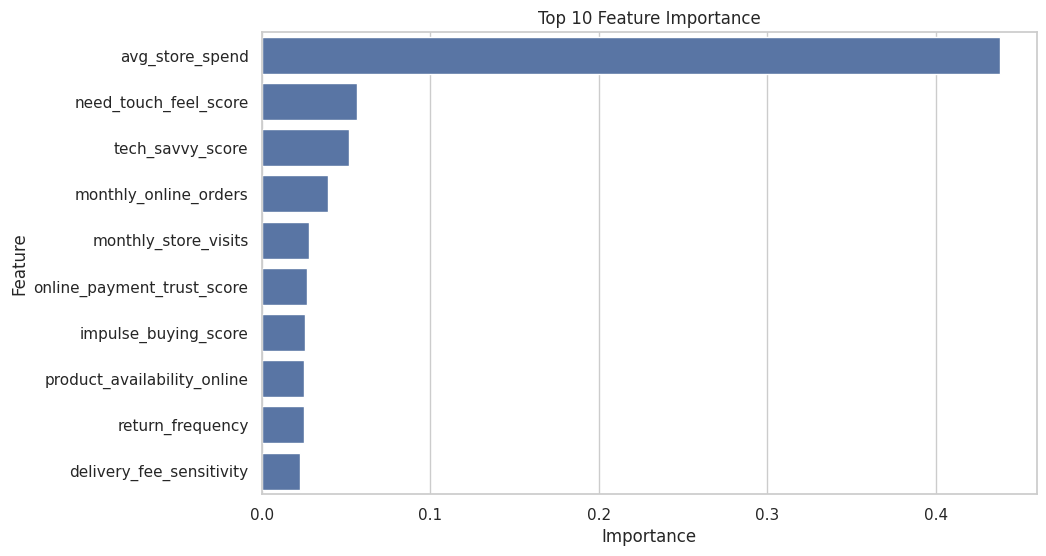

In [198]:
# FEATURE IMPORTANCE


rf = RandomForestClassifier()

rf.fit(X_train_balanced, y_train_balanced)

importance = rf.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    "Feature":features,
    "Importance":importance
}).sort_values(by="Importance", ascending=False)

print("\nTop Important Features:")
print(importance_df.head(10))

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(10))
plt.title("Top 10 Feature Importance")
plt.show()